<a href="https://colab.research.google.com/github/Sanyam0101/PYTHON-data-SCIENCE-NOTEBOOKS/blob/main/miniMLExperimentCode%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ------------------------------
# 1. Import Libraries
# ------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

In [2]:
# ------------------------------
# 2. Load Dataset
# ------------------------------
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

# Optional: map targets to class names
y = y.map({0: "setosa", 1: "versicolor", 2: "virginica"})

print("Dataset shape:", X.shape)
X.head()

Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
from google.colab import sheets
from google.colab import auth

auth.authenticate_user()
sheet = sheets.InteractiveSheet(df=X)

https://docs.google.com/spreadsheets/d/1PMfo1AjjIyhp3ocd9fnrRhilR_zaCsDdQKCPhQLtJm0/edit#gid=0


In [5]:
# ------------------------------
# 3. Check Missing Values
# ------------------------------
print("Missing values:\n", X.isnull().sum())

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [6]:
# ------------------------------
# 4. Feature Scaling
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# ------------------------------
# 5. Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

In [8]:
# ------------------------------
# 6. Train Logistic Regression
# ------------------------------
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [9]:
# ------------------------------
# 7. Evaluation
# ------------------------------
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



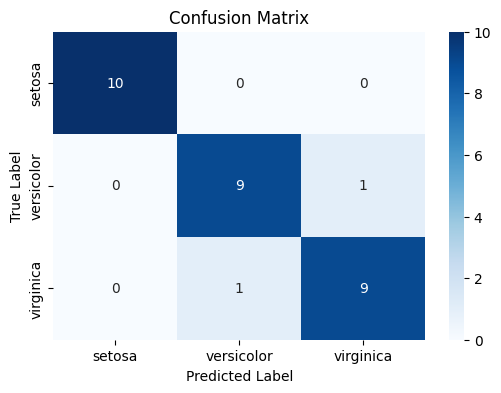

In [11]:
# ------------------------------
# 8. Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

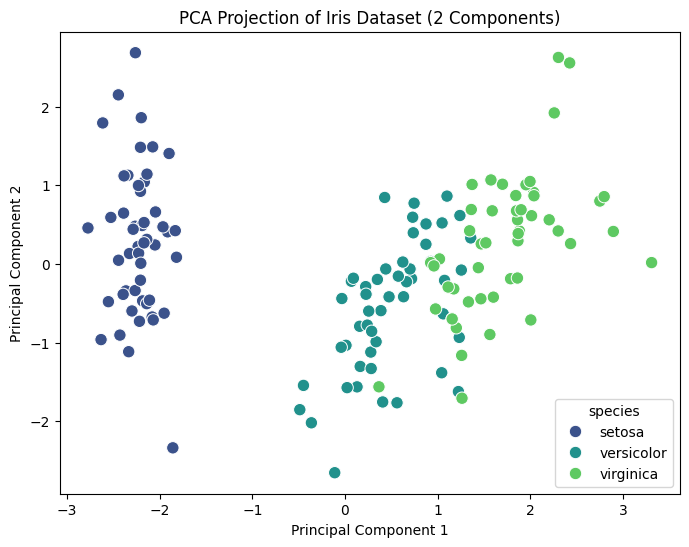

In [12]:
# ------------------------------
# 9. PCA Visualization (2D)
# ------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette="viridis",
    s=80
)
plt.title("PCA Projection of Iris Dataset (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()